In [1]:
import os
os.environ['OMP_NUM_THREADS']      = '1'
os.environ['MKL_NUM_THREADS']      = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import proj3d
from sklearn.decomposition import PCA
import pickle
import sys
sys.path.append('../..')
sys.path.append('../../results')

from utils import *
from fig2.fig2_functions import classify_all
from fig6.fig6_functions import *

In [3]:
data_root = '../../data/fig2'
sigmas    = ['sigma02', 'sigma05', 'sigma1']

data = []
for s in sigmas:
    with open(f'{data_root}/{s}/Ws.pkl', 'rb') as f:
        data.append(pickle.load(f))

solutions = [[d for d in ds if not np.all(d.get('W') == 0)] for ds in data]
matrices0 = [d['W'] for d in solutions[0]]
matrices1 = [d['W'] for d in solutions[1]]
matrices2 = [d['W'] for d in solutions[2]]

behaviours0 = np.load(f'{data_root}/behaviours/behaviours0.npy', allow_pickle=True).tolist()
behaviours1 = np.load(f'{data_root}/behaviours/behaviours1.npy', allow_pickle=True).tolist()
behaviours2 = np.load(f'{data_root}/behaviours/behaviours2.npy', allow_pickle=True).tolist()

In [4]:
# --- Select exemplar matrix (same as fig2) ---
classified = classify_all(matrices0, matrices1, matrices2,
                          behaviours0, behaviours1, behaviours2)
mat2_without_chaos = classified[2]['mat_without_chaos']

T    = 20
N    = 100
dt   = 0.005
tauE = 0.1
tauI = 0.1
a    = np.ones(N)
c    = np.ones(N)
b    = np.zeros(N)
bias = np.zeros(N)

J = mat2_without_chaos[0]
W, _ = W_from_J(J, a, b, c)
initial_conditions = init_cond(J)

ic_orbit = 0.1 * initial_conditions[:, 4]
ic_fp    = 0.1 * initial_conditions[:, 0]

In [5]:
# --- Compute frequency gradient direction v ---
v, f0, grad = compute_v(W, tauE, tauI, T, dt, a, b, c, bias,
                        ic_orbit, burn_in=4,
                        neuron_index_for_fft=0, n=80, eps=0.05)
print(f'Baseline frequency: {f0:.4f} Hz')

Baseline frequency: 1.8020 Hz


In [6]:
# --- Simulate at each alpha ---
alphas = [-2.35, -1.8, -1.18, -0.62, -0.24, 0, 0.13]
freqs_alpha, rs_alpha, g_alphas = [], [], []

for alpha in alphas:
    g_alpha = 1.0 + alpha * v
    g_alphas.append(g_alpha)
    f_alpha, r_alpha = freq_for_gains(
        g_alpha, W, tauE, tauI, T, dt, a, b, c, bias,
        ic_orbit, burn_in=4, neuron_index_for_fft=0)
    freqs_alpha.append(f_alpha)
    rs_alpha.append(r_alpha)
    print(f'alpha={alpha:.3f}  freq={f_alpha:.4f}')

alpha=-2.350  freq=0.7939
alpha=-1.800  freq=1.0031
alpha=-1.180  freq=1.2031
alpha=-0.620  freq=1.4078
alpha=-0.240  freq=1.6018
alpha=0.000  freq=1.8020
alpha=0.130  freq=1.9916


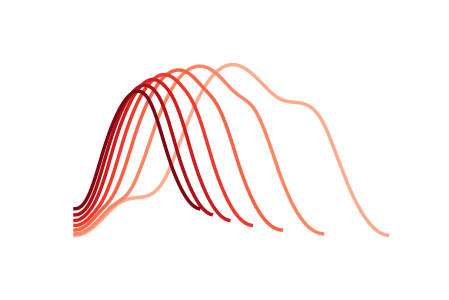

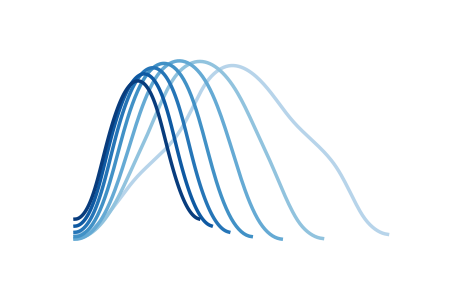

In [7]:
# --- One-cycle overlays (notebook b) ---
t = np.arange(0, T + dt, dt)
burn_in_plot = 4.0
n_cycles     = 1

reds  = discrete_shades('Reds',  len(alphas), light=0.30, dark=0.95)
blues = discrete_shades('Blues', len(alphas), light=0.30, dark=0.95)

plot_onecycle_overlay_for_neuron(
    i_neuron=1, colors=reds,
    freqs_alpha=freqs_alpha, rs_alpha=rs_alpha,
    t=t, burn_in_plot=burn_in_plot, dt=dt, n_cycles=n_cycles)
plt.show()

plot_onecycle_overlay_for_neuron(
    i_neuron=50, colors=blues,
    freqs_alpha=freqs_alpha, rs_alpha=rs_alpha,
    t=t, burn_in_plot=burn_in_plot, dt=dt, n_cycles=n_cycles)
plt.show()

In [8]:
# --- Gain-modulated trajectory with alpha schedule (notebook c) ---
burn_in      = 0.5
input_events = build_input_events(freqs_alpha, burn_in=burn_in)
T_total      = input_events[-1][1]

t, r = solve_rk4_springBox_gainmod(
    init_condition=ic_orbit,
    W=W, tauE=tauE, tauI=tauI,
    T=T_total, dt=dt,
    a=a, b=b, c=c, bias=bias,
    v=v, alphas=alphas,
    alpha_fun=lambda t, alphas: alpha_schedule(
        t, freqs_alpha, alphas, burn_in=burn_in, alpha_burn=alphas[0]),
    n=80
)

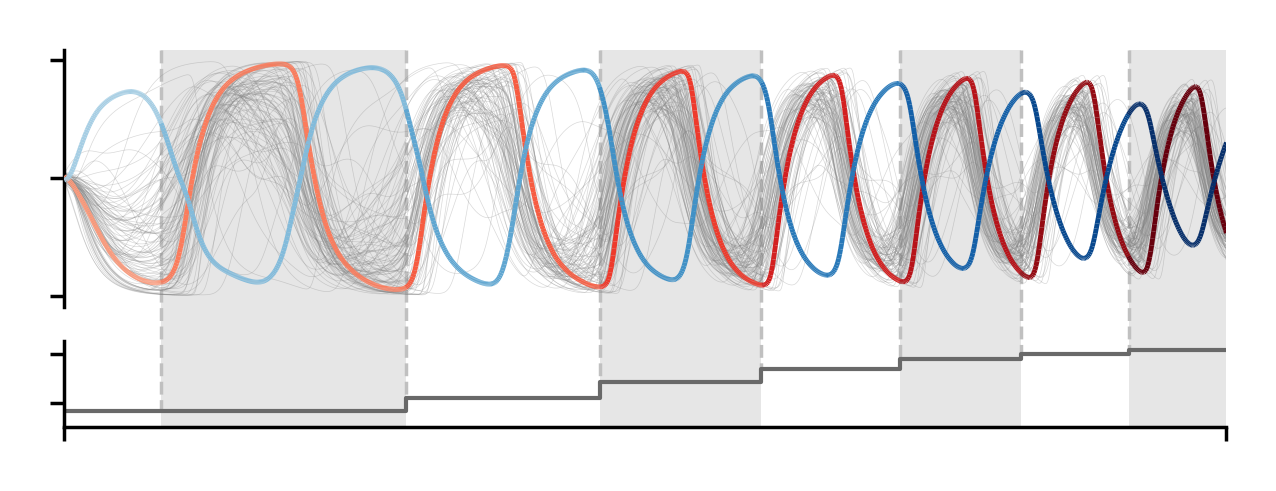

In [9]:
# --- Plot gain-modulated trajectory (notebook c) ---
bounds     = [0.0] + [ev[0] for ev in input_events[1:]] + [T_total]
alpha_vals = [alphas[0]] + list(alphas)
edges      = [ev[0] for ev in input_events] + [input_events[-1][1]]
alpha_step = list(alpha_vals) + [alpha_vals[-1]]
base_idx   = 6
idx        = [17, 4, 90]

fig, (ax, ax_alpha) = plt.subplots(
    2, 1, figsize=(3, 1), dpi=500, sharex=True,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.2})

ax.plot(t, -r, 'gray', linewidth=0.1, alpha=0.3)
plot_interval_gradient(ax, t, -r[:, idx[0]], bounds, 'Reds',
                       lw=0.7, alpha=1, dark=0.35, light=1)
plot_interval_gradient(ax, t, -r[:, idx[2]], bounds, 'Blues',
                       lw=0.7, alpha=1, dark=0.35, light=1)

ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
for s in ax.spines.values(): s.set_linewidth(0.5)
ax.tick_params(width=0.5, pad=1, length=2, labelsize=5, labelbottom=False, bottom=False)
ax.set_xticks([0, T_total]); ax.set_yticks([-0.5, 0, 0.5])
ax.set_xticklabels([]); ax.set_yticklabels([])
ax.set_xlim(0, T_total)

ax_alpha.step(edges, alpha_step, where='post', color='dimgrey', linewidth=0.6)
ax_alpha.spines['top'].set_visible(False); ax_alpha.spines['right'].set_visible(False)
for s in ax_alpha.spines.values(): s.set_linewidth(0.5)
ax_alpha.tick_params(width=0.5, pad=1, length=2, labelsize=5)
ax_alpha.set_xlim(0, T_total); ax_alpha.set_ylim(-3, 0.5)
ax_alpha.set_xticks([0, T_total])
ax_alpha.set_yticks([-2.0, 0.0]); ax_alpha.set_yticklabels(['', ''])

ax.set_facecolor('none'); ax_alpha.set_facecolor('none')
fig.canvas.draw()

for (start_time, end_time), alpha in zip(input_events[1:], alpha_vals[1:]):
    x_fig = fig.transFigure.inverted().transform(
        ax.transData.transform((start_time, 0)))[0]
    y_top = ax.get_position().y1
    _, y_alpha_disp = ax_alpha.transData.transform((start_time, alpha))
    y_alpha_fig = fig.transFigure.inverted().transform((0, y_alpha_disp))[1]
    fig.lines.append(plt.Line2D(
        [x_fig, x_fig], [y_top, y_alpha_fig],
        transform=fig.transFigure, color='silver',
        linestyle='--', linewidth=0.5, zorder=-2))

def add_section_rect(section_idx, facecolor='0.9', edgecolor='none',
                     linewidth=0.8, zorder=-10):
    start, end = input_events[section_idx]
    x0_fig = fig.transFigure.inverted().transform(ax.transData.transform((start, 0)))[0]
    x1_fig = fig.transFigure.inverted().transform(ax.transData.transform((end,   0)))[0]
    fig.patches.append(plt.Rectangle(
        (x0_fig, ax_alpha.get_position().y0),
        x1_fig - x0_fig, ax.get_position().y1 - ax_alpha.get_position().y0,
        transform=fig.transFigure, facecolor=facecolor,
        edgecolor=edgecolor, linewidth=linewidth, zorder=zorder))

for idx_sec in [s-1 for s in [2, 4, 6, 8]]:
    add_section_rect(idx_sec, facecolor='0.9', edgecolor='none', zorder=-10)
add_section_rect(6, facecolor='none', edgecolor='k', linewidth=0., zorder=5)

plt.show()

In [10]:
# --- PCA + speed-coding analysis (notebook d) ---
G    = len(rs_alpha)
burn = 500
Tt, N_dim = rs_alpha[0].shape
L    = Tt - burn

R_all = np.vstack([r[burn:, :] for r in rs_alpha])
r_range = R_all.max(axis=0) - R_all.min(axis=0)
r_range[r_range == 0] = 1.0
R_all_norm = R_all / r_range

K    = 12
pca  = PCA(n_components=K)
R_pc = pca.fit_transform(R_all_norm)          # (G*L, K)
R_pc12_groups = R_pc.reshape(G, L, K)

# Mean neural state per speed in PCs 3–12 -> speed-decoding target
X    = R_pc12_groups[:, :, 2:].mean(axis=1)  # (G, K-2)
v_bar = np.array(freqs_alpha) - np.mean(freqs_alpha)

d_ls, d_const = compare_methods(X, v_bar)
d = d_const.copy()

‣ ||d_ls|| = 1361
‣ Angle between directions [deg]: 83.06
‣ ||Xd_ls - Xd_constrained|| = 0.007995


/var/folders/46/jrxtfx3d13v4tybb9f4_lz300000gn/T/ipykernel_72179/969239481.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_d   = cm.get_cmap('copper')


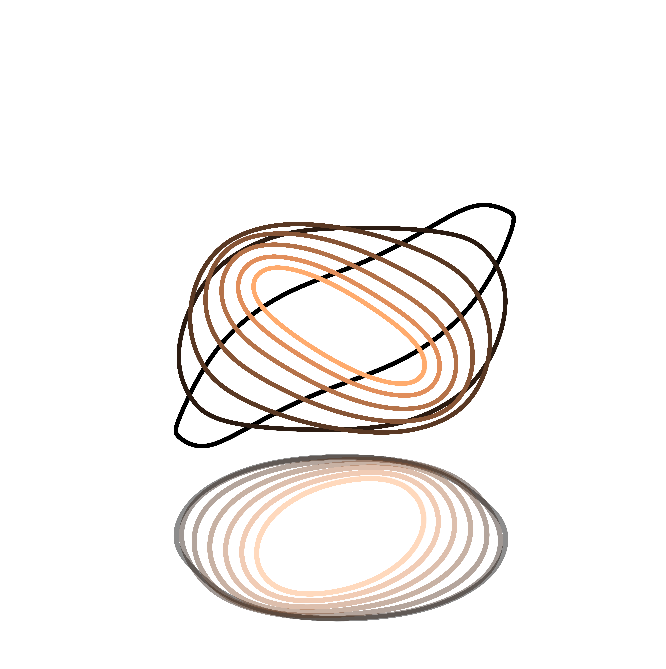

In [11]:
# --- 3D trajectory plot in PC space (notebook d) ---
pc1       = R_pc12_groups[:, :, 0]
pc2       = R_pc12_groups[:, :, 1]
beh_coord = np.tensordot(R_pc12_groups[:, :, 2:], d, axes=([2], [0]))

cmap_d   = cm.get_cmap('copper')
colors_d = cmap_d(np.linspace(0, 1, G + 1))

fig = plt.figure(figsize=(1.5, 1.5), dpi=500)
ax  = fig.add_subplot(projection='3d')

for g in range(G):
    ax.plot(pc1[g], pc2[g], beh_coord[g], color=colors_d[g], lw=0.5)

ax.grid(False)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.fill = False
    axis.pane.set_edgecolor('none')
ax.set_axis_off()
ax.view_init(elev=33, azim=45)

# shadows
fig.canvas.draw()
zmin = ax.get_zlim()[0]
for g in range(G):
    xs, ys = np.asarray(pc1[g]), np.asarray(pc2[g])
    zs = np.full_like(xs, zmin)
    xp, yp, _ = proj3d.proj_transform(xs, ys, zs, ax.get_proj())
    pts_fig = fig.transFigure.inverted().transform(
        ax.transData.transform(np.column_stack([xp, yp])))
    pts_fig[:, 1] -= 0.13
    fig.lines.append(plt.Line2D(
        pts_fig[:, 0], pts_fig[:, 1],
        transform=fig.transFigure, color=colors_d[g], linewidth=0.6, alpha=0.45))

plt.show()

In [12]:
# --- Limit-cycle landing setup (notebook e) ---
ic_orbit1 = 0.1 * initial_conditions[:, 4]
t_base, r_base = solve_rk4_springBox(ic_orbit1, W, tauE, tauI, T, dt, a, b, c, bias)

r_cyc, period_steps, idx_cycle_start = extract_reference_cycle(
    r_base, frac_discard=0.5, n_periods=1, neuron_for_period=0, min_period=20)
base_search_end = idx_cycle_start

pca_e, X_base_cycle = fit_pca_on_cycle(r_cyc, n_components=2)

In [13]:
# --- Ray initial conditions + simulate ---
ics, X_ics = make_ray_ics_from_ic1(
    ic_orbit1, pca_e, X_base_cycle,
    n_ic=20, angle=np.deg2rad(330),
    distances_frac=np.linspace(0.1, 0.9, 20),
    keep_ic1=True, both_sides=False)

rs_ic, ts_ic = [], []
for ic in ics:
    t_ic, r_ic = solve_rk4_springBox(ic, W, tauE, tauI, T, dt, a, b, c, bias)
    ts_ic.append(t_ic)
    rs_ic.append(r_ic)

In [14]:
# --- Landing detection ---
res_land = landing_and_relative_phase(
    r_base=r_base, rs_ic=rs_ic,
    r_cyc=r_cyc, period_steps=period_steps,
    base_search_end=base_search_end,
    eps_factor=0.03, min_window_periods=1.0, min_progress_cycles=0.8)
print('Base landing:', res_land['base'])

Base landing: {'j_land': 315, 'i_land': 88, 'theta_land': 4.981264027313546, 'eps': np.float64(0.06614851962924828)}


/var/folders/46/jrxtfx3d13v4tybb9f4_lz300000gn/T/ipykernel_72179/1040533126.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_e = cm.get_cmap('Purples')


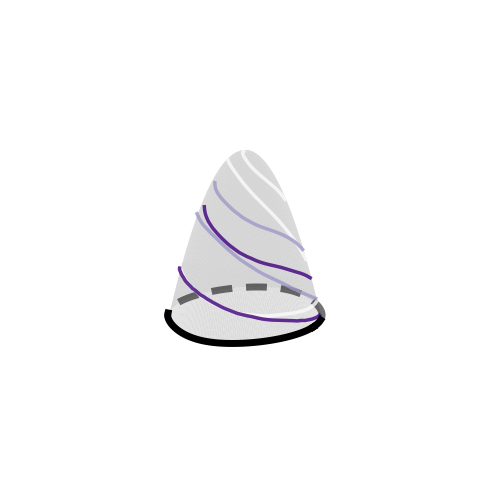

In [15]:
# --- 3D hill + trajectory overlay (notebook e) ---
keep_idxs = [0, 7, 10]

rs_ic_sel = [rs_ic[k] for k in keep_idxs]
infos_sel = [res_land['trajectories'][k] for k in keep_idxs]
X_ics_sel = X_ics[keep_idxs]

X_base_cycle_e = pca_e.transform(r_cyc)
mu = X_base_cycle_e.mean(axis=0)
X_cycle_closed = np.vstack([X_base_cycle_e, X_base_cycle_e[0:1]])

# radial hill function
V = X_base_cycle_e - mu
theta_cyc = np.arctan2(V[:, 1], V[:, 0])
rad_cyc   = np.sqrt(V[:, 0]**2 + V[:, 1]**2)
n_bins    = 1000
theta_bins = np.linspace(-np.pi, np.pi, n_bins + 1)
theta_cent = 0.5 * (theta_bins[:-1] + theta_bins[1:])
R = np.full(n_bins, np.nan)
bin_id = np.clip(np.digitize(theta_cyc, theta_bins) - 1, 0, n_bins - 1)
for k in range(n_bins):
    rk = rad_cyc[bin_id == k]
    if rk.size: R[k] = np.percentile(rk, 95)
good = np.isfinite(R)
R = np.interp(np.arange(n_bins), np.where(good)[0], R[good])
theta_ext = np.r_[theta_cent - 2*np.pi, theta_cent, theta_cent + 2*np.pi]
R_ext     = np.r_[R, R, R]

def hill_z(xy, zmax=1.0, p=2.0):
    xy = np.asarray(xy)
    Vp = xy - mu
    th = np.arctan2(Vp[..., 1], Vp[..., 0])
    rr = np.sqrt(Vp[..., 0]**2 + Vp[..., 1]**2)
    Rth = np.interp(th, theta_ext, R_ext)
    s = rr / np.maximum(Rth, 1e-12)
    return np.where(s <= 1.0, zmax * (1.0 - np.clip(s, 0, 1)**p), 0.0)

def downsample_idx(n, max_points=350):
    return np.arange(n) if n <= max_points else np.linspace(0, n-1, max_points).astype(int)

def proj_figfrac(ax, fig, xs, ys, zs):
    x2, y2, _ = proj3d.proj_transform(xs, ys, zs, ax.get_proj())
    return fig.transFigure.inverted().transform(
        ax.transData.transform(np.column_stack([x2, y2])))

def front_score(xy, center, azim_deg):
    az = np.deg2rad(azim_deg)
    vxy = np.array([np.cos(az), np.sin(az)])
    vxy /= np.linalg.norm(vxy) + 1e-12
    return (xy - center[None, :]) @ vxy

# build trajectory data
cmap_e = cm.get_cmap('Purples')
colors_e = cmap_e(np.linspace(0, 1, len(keep_idxs)))
traj_data = []
all_X_bounds = [X_base_cycle_e]
overlay_max = 500
for info, r_traj in zip(infos_sel, rs_ic_sel):
    j = info.get('j_land')
    if j is None or j < 2: continue
    X = pca_e.transform(r_traj)
    j = min(j, X.shape[0] - 1)
    Xseg = X[:j+1]
    zseg = hill_z(Xseg)
    idx_ds = downsample_idx(len(Xseg), overlay_max)
    traj_data.append(dict(
        xs=Xseg[idx_ds, 0], ys=Xseg[idx_ds, 1], zs=zseg[idx_ds],
        start=(float(Xseg[0, 0]),  float(Xseg[0, 1]),  float(zseg[0])),
        land =(float(Xseg[-1, 0]), float(Xseg[-1, 1]), 0.0)))
    all_X_bounds.append(Xseg)

all_X_bounds = np.vstack(all_X_bounds)
xmin, xmax = all_X_bounds[:, 0].min(), all_X_bounds[:, 0].max()
ymin, ymax = all_X_bounds[:, 1].min(), all_X_bounds[:, 1].max()
pad = 0.15 * max(xmax-xmin, ymax-ymin)
xmin, xmax = xmin-pad, xmax+pad
ymin, ymax = ymin-pad, ymax+pad

# hill surface
ngrid = 140
xx, yy = np.linspace(xmin, xmax, ngrid), np.linspace(ymin, ymax, ngrid)
XX, YY = np.meshgrid(xx, yy)
ZZ = hill_z(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

hill_rgba  = np.array(mcolors.to_rgba('lightgrey'))
floor_rgba = np.array(mcolors.to_rgba('white'))
Zface = 0.25*(ZZ[:-1,:-1]+ZZ[1:,:-1]+ZZ[:-1,1:]+ZZ[1:,1:])
facecolors = np.where(Zface[..., None] <= 1e-10, floor_rgba, hill_rgba)

fig = plt.figure(figsize=(1, 1), dpi=500)
ax3d = fig.add_subplot(projection='3d')
ax3d.view_init(elev=18, azim=24)
ax3d.set_proj_type('ortho')
ax3d.set_box_aspect((1, 1, 0.7))
ax3d.set_xlim(xmin, xmax); ax3d.set_ylim(ymin, ymax); ax3d.set_zlim(0, 1)
ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])
ax3d.grid(False)
for axis in (ax3d.xaxis, ax3d.yaxis, ax3d.zaxis):
    axis.pane.fill = False
    axis.pane.set_edgecolor((1,1,1,0))
ax3d.xaxis.line.set_alpha(0); ax3d.yaxis.line.set_alpha(0); ax3d.zaxis.line.set_alpha(0)
ax3d.patch.set_alpha(0.0)
ax3d.plot_surface(XX, YY, ZZ, facecolors=facecolors,
                  rstride=1, cstride=1, linewidth=0,
                  antialiased=True, shade=False, alpha=0.8)

# figure-level overlays
overlay_lines = []
for i in range(len(traj_data)):
    ln = Line2D([], [], lw=0.5, color=colors_e[i], alpha=0.8,
                transform=fig.transFigure, zorder=1200)
    fig.add_artist(ln); overlay_lines.append(ln)

cyc_idx = downsample_idx(len(X_cycle_closed), 300)
cycle_front = Line2D([], [], lw=1., color='0.0', alpha=1.0,
                     transform=fig.transFigure, zorder=1300)
cycle_back  = Line2D([], [], lw=1., color='0.0', alpha=0.55,
                     linestyle=(0,(3,2)), transform=fig.transFigure, zorder=1100)
fig.add_artist(cycle_back); fig.add_artist(cycle_front)

def update_overlay(event=None):
    cyc_xy = np.column_stack([X_cycle_closed[cyc_idx, 0], X_cycle_closed[cyc_idx, 1]])
    mask_f = front_score(cyc_xy, mu, ax3d.azim) > 0
    cyc = proj_figfrac(ax3d, fig,
                       X_cycle_closed[cyc_idx, 0],
                       X_cycle_closed[cyc_idx, 1],
                       np.zeros(len(cyc_idx)))
    fx, fy = cyc[:, 0], cyc[:, 1]
    ff, bf = fx.copy(), fx.copy()
    ff[~mask_f] = np.nan; bf[mask_f] = np.nan
    cycle_front.set_data(ff, np.where(~np.isnan(ff), fy, np.nan))
    cycle_back.set_data(bf,  np.where(~np.isnan(bf), fy, np.nan))
    for i, (ln, td) in enumerate(zip(overlay_lines, traj_data)):
        xy = np.column_stack([td['xs'], td['ys']])
        front = front_score(xy, mu, ax3d.azim) > 0.01
        pts = proj_figfrac(ax3d, fig, td['xs'], td['ys'], td['zs'])
        fx2, fy2 = pts[:, 0].copy(), pts[:, 1].copy()
        fx2[~front] = np.nan; fy2[~front] = np.nan
        ln.set_data(fx2, fy2)
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_release_event', update_overlay)
update_overlay()
plt.show()